# Ne₂ Potential Energy Surface (Quick QEpy XC-Mix Demo)

This notebook demonstrates a **fast PES scan** for a neon dimer (Ne₂) using QEpy, and compares how different exchange-correlation choices change the curve shape.

We scan the Ne–Ne distance \(R\) and evaluate total energies for:

- `PBE`
- `0.50*PBE + 0.50*RVV10`
- `RVV10`

## Why this example is useful

- **Very small system** (2 atoms) -> quick in Jupyter
- **Gamma-only sampling** -> low computational cost
- **Short distance grid** -> fast turnaround
- **Clear physics** -> semilocal vs nonlocal-vdW behavior is easy to compare

## Notebook outputs

- `ne2_pes_quick.csv` with raw PES data
- `ne2_pes_quick.pdf` with relative-energy plots
- per-XC equilibrium estimate (`R_eq`) and minimum energy (`E_min`) printed in the output

In [1]:
# Download Ne pseudopotential once into the notebook folder.
!curl -L "http://www.quantum-simulation.org/potentials/sg15_oncv/upf/Ne_ONCV_PBE-1.2.upf" -o "Ne_ONCV_PBE-1.2.upf"
#!wget "http://www.quantum-simulation.org/potentials/sg15_oncv/upf/Ne_ONCV_PBE-1.2.upf" # For Linux

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 90155  100 90155    0     0   241k      0 --:--:-- --:--:-- --:--:--  241k


In [ ]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!pip install qepy
!pip install dftpy
!pip install matplotlib

## 2) Imports and helpers

Import NumPy, ASE atom utilities, and QEpy PES helpers:
- `Driver.compute_pes` for scan orchestration
- `scf_xc_mix` for mixed-XC SCF evaluations
- `make_label` for readable XC labels in logs and plots

In [7]:
# Core numerical tools + QEpy helpers for PES scans.
import numpy as np
from ase import Atoms
from qepy.driver import Driver
from qepy.pes import make_label, scf_xc_mix

## 3) Build and update Ne₂ geometry

Define helper functions to:
- create a centered Ne₂ dimer in a cubic box
- update only the Ne–Ne separation \(R\) during the scan

In [8]:
def make_ne2(R=3.6, box=14.0):
    """Ne₂ along z, centered in a cubic supercell (Å)."""
    z0 = 0.5 * box
    h = 0.5 * R
    positions = [[0.5 * box, 0.5 * box, z0 - h], [0.5 * box, 0.5 * box, z0 + h]]
    cell = np.diag([box, box, box])
    return Atoms("Ne2", positions=positions, cell=cell, pbc=True)

def set_ne2_distance(atoms, R):
    """Return a copy with Ne–Ne distance R (Å), keeping the dimer centered in the cell."""
    atoms = atoms.copy()
    c = atoms.get_cell().diagonal()
    box = float(c[2])
    z0 = 0.5 * box
    h = 0.5 * R
    # Keep x,y fixed at cell center; only scan the z-separation.
    atoms.positions[0] = [0.5 * c[0], 0.5 * c[1], z0 - h]
    atoms.positions[1] = [0.5 * c[0], 0.5 * c[1], z0 + h]
    return atoms

## 4) Base QE options (`qe_options`)

Define a reusable QE input dictionary:
- SCF control settings
- plane-wave/system settings
- electronic convergence settings
- atomic species, cell, k-point sampling

Only atomic positions are changed during the PES scan.

In [9]:
# Base QE input options for Ne2 (R=3.6 A in a 14 A cubic box).
# We keep this dict explicit so learners can see exactly what is sent to QE.
qe_options = {
    "&control": {
        "calculation": "'scf'",
        "pseudo_dir": "'./'",
        "tprnfor": True,
        "tstress": True,
        "disk_io": "'none'",
        "verbosity": "'low'",
        "restart_mode": "'from_scratch'",
    },
    "&system": {
        "ibrav": 0,
        "ecutwfc": 40,
        "nat": 2,
        "ntyp": 1,
        "occupations": "'fixed'",
        "nosym": True,
        "noinv": True,
    },
    "&electrons": {
        "conv_thr": 1e-7,
        "electron_maxstep": 120,
        "mixing_beta": 0.5,
    },
    "atomic_species": ["Ne 20.1797 Ne_ONCV_PBE-1.2.upf"],
    "atomic_positions angstrom": [
        # Initial geometry at R=3.6 A (updated during the scan below).
        "Ne 7.0000000000 7.0000000000 5.2000000000",
        "Ne 7.0000000000 7.0000000000 8.8000000000",
    ],
    "cell_parameters angstrom": [
        "14.0000000000 0.0000000000 0.0000000000",
        "0.0000000000 14.0000000000 0.0000000000",
        "0.0000000000 0.0000000000 14.0000000000",
    ],
    # Gamma-only sampling keeps this example fast.
    "k_points automatic": ["1 1 1 0 0 0"],
}


## 5) XC definitions and per-point evaluator

Set the XC mixes to compare, then define:

- `update_ne2(...)`: updates positions for a given distance \(R\)
- `calc_xc_energies(R)`: runs SCF for each XC option at that \(R\)

This function is the workhorse passed into the PES driver.

In [10]:
# Reference atoms object used only to generate updated coordinates.
ne2 = make_ne2(R=3.6, box=14.0)

# Compare semilocal, mixed, and pure nonlocal-vdW style curves.
# Keep list short to keep runtime short.
xc_list = [
    {"PBE": 1.0},
    {"PBE": 0.50, "RVV10": 0.50},
    {"RVV10": 1.0},
]

def update_ne2(qe_opts, R):
    """Return qe_options with Ne positions replaced for distance R."""
    atoms_R = set_ne2_distance(ne2, R)
    qe_opts = dict(qe_opts)
    qe_opts["atomic_positions angstrom"] = [
        f"Ne {p[0]:.10f} {p[1]:.10f} {p[2]:.10f}"
        for p in atoms_R.positions
    ]
    return qe_opts

def calc_xc_energies(R):
    """Compute total energies at one R for all XC mixes in xc_list."""
    opts = update_ne2(qe_options, R)
    return {
        make_label(xc): scf_xc_mix(
            opts,
            xc,
            maxiter=50,
            logfile=f"pes_ne2_{make_label(xc).replace(' ', '_')}_{R:.3f}.out",
        )
        for xc in xc_list
    }

## 6) Run PES scan

Create a short distance grid and call `Driver.compute_pes(...)`.

This returns:
- scanned distances
- an energy array for each XC label

and writes CSV output for later reuse.

In [11]:
# Short distance grid for fast notebook execution.
R_grid = np.linspace(2.4, 5.2, 7)

# Driver.compute_pes loops over R_grid and stores one curve per XC label.
R_grid, energies = Driver.compute_pes(
    R_grid,
    calc_xc_energies,
    scan_label="R (A)",
    save_csv="ne2_pes_quick.csv",
)

PES scan: 7 points along R (A)

[1/7] R (A) = 2.400000
  PBE: E = -122.7161038345
  0.5*PBE + 0.5*RVV10: E = -122.7815873240
  RVV10: E = -122.8472634140

[2/7] R (A) = 2.866667
  PBE: E = -122.7202651586
  0.5*PBE + 0.5*RVV10: E = -122.7854168869
  RVV10: E = -122.8507581614

[3/7] R (A) = 3.333333
  PBE: E = -122.7203274851
  0.5*PBE + 0.5*RVV10: E = -122.7854065280
  RVV10: E = -122.8506760341

[4/7] R (A) = 3.800000
  PBE: E = -122.7201211705
  0.5*PBE + 0.5*RVV10: E = -122.7851795693
  RVV10: E = -122.8504281425

[5/7] R (A) = 4.266667
  PBE: E = -122.7200216536
  0.5*PBE + 0.5*RVV10: E = -122.7850755954
  RVV10: E = -122.8503189104

[6/7] R (A) = 4.733333
  PBE: E = -122.7199985240
  0.5*PBE + 0.5*RVV10: E = -122.7850705684
  RVV10: E = -122.8503319909

[7/7] R (A) = 5.200000
  PBE: E = -122.7200001119
  0.5*PBE + 0.5*RVV10: E = -122.7850904211
  RVV10: E = -122.8503704881

PES scan complete.
Results saved to ne2_pes_quick.csv


## 7) Plot PES and report minima

Plot relative energies $(E - E_{\min})$ in eV for each XC curve,
and print:
- equilibrium distance estimate (`R_eq`)
- minimum absolute energy (`E_min`)

PBE: R_eq = 3.333 A, E_min = -122.7203274851 Ha
0.5*PBE + 0.5*RVV10: R_eq = 2.867 A, E_min = -122.7854168869 Ha
RVV10: R_eq = 2.867 A, E_min = -122.8507581614 Ha


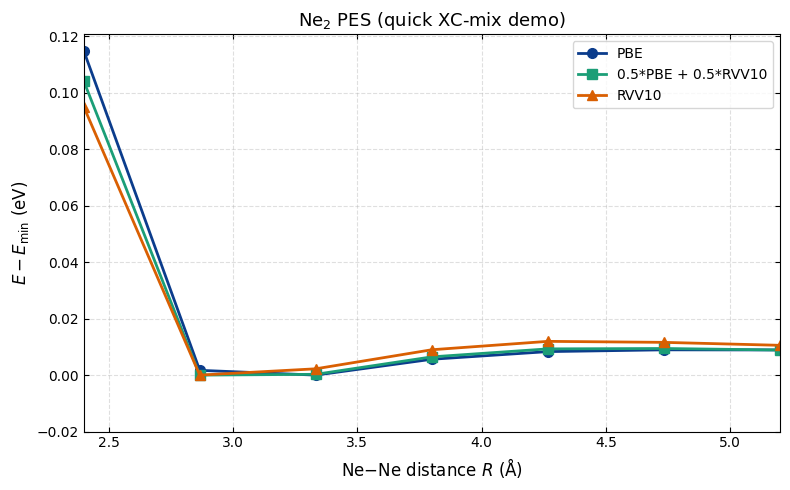

In [13]:
import matplotlib.pyplot as plt

# Convert relative energies to eV for easier visual comparison.
Ha_to_eV = 27.2114
markers = ["o", "s", "^", "D"]
colors = ["#0b3c8c", "#1b9e77", "#d95f02", "#7570b3"]

fig, ax = plt.subplots(figsize=(8, 5))

# Plot one PES curve per XC definition.
for idx, (label, E) in enumerate(energies.items()):
    E_rel = (E - E.min()) * Ha_to_eV
    ax.plot(
        R_grid,
        E_rel,
        marker=markers[idx % len(markers)],
        color=colors[idx % len(colors)],
        label=label,
        linewidth=2,
        markersize=7,
    )
    # Print equilibrium distance and absolute minimum energy for each curve.
    R_eq = R_grid[np.argmin(E)]
    print(f"{label}: R_eq = {R_eq:.3f} A, E_min = {E.min():.10f} Ha")

ax.set_xlabel(r"Ne$-$Ne distance $R$ ($\mathrm{\AA}$)", fontsize=12)
ax.set_ylabel(r"$E - E_{\mathrm{min}}$ (eV)", fontsize=12)
ax.set_title("Ne$_2$ PES (quick XC-mix demo)", fontsize=13)
ax.set_xlim(R_grid.min(), R_grid.max())
ax.set_ylim(-0.02, None)
ax.legend(fontsize=10, loc="best")
ax.grid(True, which="both", ls="--", alpha=0.4)
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)

plt.tight_layout()
plt.savefig("ne2_pes_quick.pdf", bbox_inches="tight")
plt.show()